# Samples, pipeline, and tables


## Setup


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numba
import numba.typed

from pathlib import Path
import tqdm
import sys
import seaborn as sns
import scipy.stats
import scipy.optimize
import scipy.special
import os
import pysam
import pprint
import pickle
import joblib
import subprocess
import polars as pl
import io
import glob
import logging

os.environ["PATH"] += ":" + os.path.join(sys.prefix, "bin")
import pybedtools

pd.set_option('display.max_rows', 1000)
plt.rcParams["pdf.use14corefonts"] = True
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.sans-serif"] = ["Helvetica"]
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


In [3]:
repo = Path(os.getcwd())
if repo.name == "notebooks":
    repo = repo.parent
elif not (repo / "configs").exists():
    repo = Path("/nfs/users/nfs_r/rs42/rs42/git/recombination")

sys.path.append(str(repo))
from src.IDs import *

figure_dir = repo / "figures"
table_dir = repo / "tables"
figure_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)


In [4]:
rahbari_df = pl.read_csv(repo / "configs/Rahbari.tsv", separator='	')

sudmant_df = (
    pl.read_csv(repo / "configs/Sudmant.tsv", separator='	')
    .with_columns(
        pl.col("sample_set").cast(pl.String),
        pl.col("sample_id").cast(pl.String),
        pl.col("flow_cell").cast(pl.String),
    )
)

CEPH_df = pl.read_csv(repo / "configs/CEPH.tsv", separator='	')
ceph_df = CEPH_df

ceph_sample_ids_no_gps = sorted([
    x for x in CEPH_df["sample_id"].unique().to_list()
    if x not in ["NA12889", "NA12890", "NA12891", "NA12892"]
])

sample_ids = rahbari_sample_ids + sudmant_sample_ids


## Samples


In [5]:
flow_cell_stats_df = (
    pl.read_csv(
        "/lustre/scratch122/tol/projects/sperm/analysis/sequence_throughput/sequence_throughput_per_movie.csv"
    )
    .with_columns(
        sample_id = pl.col("Sample"),
        coverage = pl.col("Coverage").cast(pl.Float64),
        count = pl.col("Read count").cast(pl.Int64),
        mean = pl.col("Mean length (bp)").str.split(by=' ± ').list.first().cast(pl.Float64),
        std = pl.col("Mean length (bp)").str.split(by=' ± ').list.last().cast(pl.Float64),
    )
)

unique_ids = pl.concat([
    rahbari_df["flow_cell"],
    sudmant_df["flow_cell"],
    CEPH_df["flow_cell"],
    flow_cell_stats_df.filter(pl.col("Sample").is_in(["PD47269d", "PD48473b"]))["Movie"],
]).unique()

stats_df = (flow_cell_stats_df.filter(pl.col("Movie").is_in(unique_ids)))
coverage_per_sample = stats_df.group_by("sample_id").agg(pl.col("coverage").sum())


In [6]:
sample_tables = []
for ids in rahbari_sample_ids+sudmant_sample_ids, ceph_sample_ids_no_gps:
    df = (
        (stats_df
            .filter(pl.col("sample_id").is_in(ids))
            .group_by("sample_id")
            .agg(
                n_reads = pl.col("count").sum(),
                mean_read_length = ((pl.col("mean") * pl.col("count")).sum() / pl.col("count").sum()),
                std_read_length = ((pl.col("std") * pl.col("count")).sum() / pl.col("count").sum()),
            )
        )
        .join(
            pl.DataFrame(
                {
                    "sample_id": sample_presentation_order, 
                    "paper_label_id": [sample_id_to_paper_label[x] for x in sample_presentation_order]
                }
            ),
            on="sample_id",
            how="left",
        )
        .join(
            coverage_per_sample,
            on="sample_id",
            how="left",
        )
        .join(
            (stats_df
                .pivot(
                    values=["Instrument"],
                    index=["sample_id"],
                    on=["Instrument"],
                    aggregate_function='len'
                ) 
                .fill_null(0)
            ),
            on="sample_id",
            how="left",
        )
        .sort("paper_label_id", "sample_id")
        .select(
            "paper_label_id",
            "sample_id",
            "n_reads",
            pl.format("{} ± {}", pl.col("mean_read_length").cast(int), pl.col("std_read_length").cast(int)).alias("read_length"),
            "coverage",
        )
    )
    sample_tables.append(df)
    with pl.Config(thousands_separator=",", float_precision=2, tbl_rows=40):
        display(df)

table_s1, table_s2 = sample_tables
with pd.ExcelWriter(table_dir / "sample_metadata_tables.xlsx") as writer:
    table_s1.to_pandas().to_excel(writer, sheet_name="Table S1", index=False)
    table_s2.to_pandas().to_excel(writer, sheet_name="Table S2", index=False)


paper_label_id,sample_id,n_reads,read_length,coverage
str,str,i64,str,f64
"""AA1-s1""","""PD50508b""","14,366,105","""12647 ± 4536""",60.58
"""AA1-s2""","""PD50508f""","3,040,994","""17011 ± 3308""",17.25
"""AA2-t1""","""PD46180c""","29,375,470","""13929 ± 5568""",136.38
"""AA2-t2""","""PD50519d""","33,329,411","""12047 ± 5315""",133.84
"""AA3""","""PD50477f""","38,422,720","""11232 ± 4354""",143.85
"""AA4""","""PD50489e""","25,190,427","""10548 ± 5358""",88.58
"""AA5""","""1894""","9,181,559","""17527 ± 4909""",53.65
"""AA6""","""3898""","8,634,738","""17985 ± 4982""",51.76
"""AA7""","""7899""","5,367,893","""16846 ± 4671""",30.14


paper_label_id,sample_id,n_reads,read_length,coverage
str,str,i64,str,f64
null,"""200100""","6,619,579","""12059 ± 4021""",26.61
null,"""200101""","9,188,613","""10183 ± 4541""",31.20
null,"""200102""","9,387,139","""12443 ± 5279""",38.94
null,"""200104""","5,045,933","""12890 ± 5513""",21.68
null,"""200106""","4,635,172","""13215 ± 4344""",20.42
null,"""NA12877""","11,128,682","""17804 ± 3246""",66.04
null,"""NA12878""","11,480,931","""16119 ± 3558""",61.69
null,"""NA12879""","4,933,624","""17756 ± 4595""",29.21
null,"""NA12881""","5,187,297","""22961 ± 4870""",39.71


In [7]:
sperm_stats_df = stats_df.filter(pl.col("sample_id").is_in(rahbari_sample_ids + sudmant_sample_ids))
ceph_stats_df = stats_df.filter(pl.col("sample_id").is_in(ceph_sample_ids_no_gps))

sperm_mean_read_length = (sperm_stats_df["mean"] * sperm_stats_df["count"]).sum() / sperm_stats_df["count"].sum()
blood_mean_read_length = (ceph_stats_df["mean"] * ceph_stats_df["count"]).sum() / ceph_stats_df["count"].sum()

print("Average read length, sperm:", sperm_mean_read_length)
print("Average read length, CEPH blood:", blood_mean_read_length)


Average read length, sperm: 13160.820895532914
Average read length, CEPH blood: 14479.788050218396


## Read counts


In [8]:
reads_df = pl.concat(
    [
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/Rahbari_20250212/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/all_reads_structure_annotated.parquet",
        ) 
        for sample_id, sample_set in tqdm.tqdm(rahbari_df.select("sample_id", "sample_set").unique().iter_rows())
        for chrom in aut_chrom_names
    ] + 
    [
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/all_reads_structure_annotated.parquet",
        ) 
        for sample_id, sample_set in tqdm.tqdm(sudmant_df.select("sample_id", "sample_set").unique().iter_rows())
        for chrom in aut_chrom_names
    ]
)

ceph_reads_df = pl.concat(
    [
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/CEPH_20250212/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/all_reads_structure_annotated.parquet",
        ) 
        for sample_id, sample_set in tqdm.tqdm(ceph_df.select("sample_id", "sample_set").unique().iter_rows())
        for chrom in aut_chrom_names
        if sample_id in ceph_sample_ids_no_gps
    ] 
)

n_high_quality_reads = (reads_df
    .filter(pl.col("is_high_quality_read"))
    .select(pl.len())
).collect(streaming=True).item()

n_high_quality_blood_reads = (ceph_reads_df
    .filter(pl.col("is_high_quality_read"))
    .select(pl.len())
).collect(streaming=True).item()

sperm_total_reads = stats_df.filter(pl.col("sample_id").is_in(sample_ids))["count"].sum()
blood_total_reads = stats_df.filter(pl.col("sample_id").is_in(ceph_sample_ids_no_gps))["count"].sum()

print("Total number of reads, sperm:", sperm_total_reads)
print("High-quality reads, sperm:", n_high_quality_reads)
print("Total number of reads, CEPH blood:", blood_total_reads)
print("High-quality reads, CEPH blood:", n_high_quality_blood_reads)


9it [00:00, 2158.67it/s]
6it [00:00, 2885.00it/s]
16it [00:00, 4422.62it/s]


Total number of reads, sperm: 267461560
High-quality reads, sperm: 196296004
Total number of reads, CEPH blood: 94043625
High-quality reads, CEPH blood: 68246339


## SNV counts


56it [00:00, 3771.25it/s]
12it [00:00, 4121.49it/s]
52it [00:00, 4698.79it/s]
56it [03:39,  3.92s/it]
12it [00:57,  4.79s/it]


Read SNV calls, sperm: 3021086931
High-quality SNVs, sperm: 1163633539
Reads with high-quality SNVs: 173695261
Mean SNVs/read: 6.699282020135253
High-quality SNVs, CEPH blood: 389685716


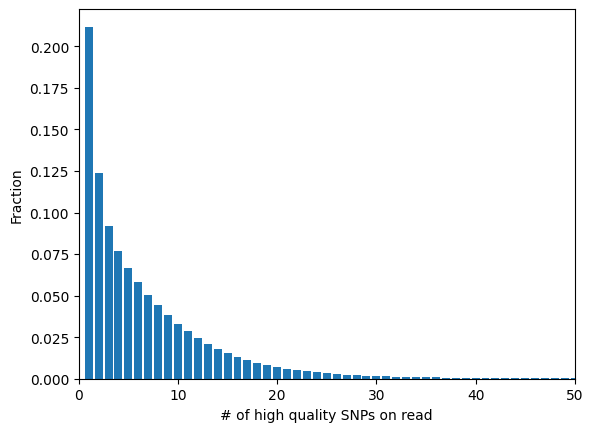

In [19]:
all_snps = pl.concat(
    [
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/Rahbari_20250212/read_analysis/{sample_set}/{sample_id}/{flow_cell}/{chrom}/annotated_0.95_high_confidence_snps.parquet",
        ) 
        for sample_id, sample_set, flow_cell in tqdm.tqdm(rahbari_df.select("sample_id", "sample_set", "flow_cell").iter_rows())
        for chrom in aut_chrom_names
    ] + 
    [
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121/read_analysis/{sample_set}/{sample_id}/{flow_cell}/{chrom}/annotated_0.95_high_confidence_snps.parquet",
        ) 
        for sample_id, sample_set, flow_cell in tqdm.tqdm(sudmant_df.select("sample_id", "sample_set", "flow_cell").iter_rows())
        for chrom in aut_chrom_names
    ]
)

n_sperm_read_snv_calls = all_snps.select(pl.len()).collect().item()

all_ceph_snps = pl.concat(
    [
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/CEPH_20250212/read_analysis/{sample_set}/{sample_id}/{flow_cell}/{chrom}/annotated_0.95_high_confidence_snps.parquet",
        )
        for sample_id, sample_set, flow_cell in tqdm.tqdm(CEPH_df.select("sample_id", "sample_set", "flow_cell").iter_rows())
        for chrom in aut_chrom_names
        if sample_id in ceph_sample_ids_no_gps
    ] 
)

n_blood_high_quality_snvs = (
    all_ceph_snps
    .select("read_name", "start", "is_high_quality_snp")
    .collect()
    .filter("is_high_quality_snp")
    .select(pl.len())
    .item()
)

rows = []

for sample_id, sample_set, flow_cell in tqdm.tqdm(rahbari_df.select("sample_id", "sample_set", "flow_cell").iter_rows()):
    for chrom in aut_chrom_names:        
        sample_snps =             pl.scan_parquet(
                f"/lustre/scratch122/tol/projects/sperm/results/Rahbari_20250212/read_analysis/{sample_set}/{sample_id}/{flow_cell}/{chrom}/annotated_0.95_high_confidence_snps.parquet",
            ) 

        unique_snp_counts = (sample_snps
            .filter("is_high_quality_snp")
            .group_by("read_name")
            .len().rename({"len": "n_snps"})
            .group_by("n_snps")
            .len()
            .collect(streaming=True)
        )
        rows.append((sample_id, sample_set, flow_cell, chrom, unique_snp_counts))
        
for sample_id, sample_set, flow_cell in tqdm.tqdm(sudmant_df.select("sample_id", "sample_set", "flow_cell").iter_rows()):
    for chrom in aut_chrom_names:        
        sample_snps =             pl.scan_parquet(
                f"/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121/read_analysis/{sample_set}/{sample_id}/{flow_cell}/{chrom}/annotated_0.95_high_confidence_snps.parquet",
            ) 

        unique_snp_counts = (sample_snps
            .filter("is_high_quality_snp")
            .group_by("read_name")
            .len().rename({"len": "n_snps"})
            .group_by("n_snps")
            .len()
            .collect(streaming=True)
        )
        rows.append((sample_id, sample_set, flow_cell, chrom, unique_snp_counts))        

total_hist = {s:np.zeros(400) for s in sample_ids + ["All"]}
for row in rows:
    for n_snps, cnt in row[-1].rows():
        total_hist[str(row[0])][n_snps] += cnt
        total_hist["All"][n_snps] += cnt

n_high_quality_snvs = int(sum(n_snps * cnt for row in rows for n_snps, cnt in row[-1].rows()))
n_reads_with_high_quality_snvs = int(total_hist["All"].sum())
mean_snvs_per_read = n_high_quality_snvs / n_reads_with_high_quality_snvs

plt.bar(x=np.arange(400), height=total_hist["All"] / total_hist["All"].sum())
plt.xlim(0, 50)
plt.xlabel("# of high quality SNPs on read");
plt.ylabel("Fraction");

plt.rcParams["pdf.use14corefonts"] = True
fig = plt.gcf()
fig.savefig(figure_dir / "snv_count_distribution.pdf")

print("Read SNV calls, sperm:", n_sperm_read_snv_calls)
print("High-quality SNVs, sperm:", n_high_quality_snvs)
print("Reads with high-quality SNVs:", n_reads_with_high_quality_snvs)
print("Mean SNVs/read:", mean_snvs_per_read)
print("High-quality SNVs, CEPH blood:", n_blood_high_quality_snvs)


## Event counts


In [20]:
rahbari_reads_filenames = [
    (
        f"/lustre/scratch122/tol/projects/sperm/results/Rahbari_20250212/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/all_reads_structure_annotated.parquet",
    ) 
    for sample_id, sample_set in tqdm.tqdm(rahbari_df.select("sample_id", "sample_set").unique().iter_rows())
    for chrom in aut_chrom_names
]

sudmant_reads_filenames = [
    (
        f"/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/all_reads_structure_annotated.parquet",
    ) 
    for sample_id, sample_set in tqdm.tqdm(sudmant_df.select("sample_id", "sample_set").unique().iter_rows())
    for chrom in aut_chrom_names
]

ceph_reads_filenames = [
    (
        f"/lustre/scratch122/tol/projects/sperm/results/CEPH_20250212/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/all_reads_structure_annotated.parquet",
    ) 
    for sample_id, sample_set in tqdm.tqdm(ceph_df.select("sample_id", "sample_set").unique().iter_rows())
    for chrom in aut_chrom_names
    if sample_id in ceph_sample_ids_no_gps
]

all_filenames = rahbari_reads_filenames + sudmant_reads_filenames + ceph_reads_filenames
reads_filenames = rahbari_reads_filenames + sudmant_reads_filenames


9it [00:00, 52943.53it/s]
6it [00:00, 12813.56it/s]
16it [00:00, 83676.89it/s]


In [21]:
n_rahbari_classified_reads = (
    pl.concat([
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/Rahbari_20250212/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/classified_reads.parquet",
        ) 
        for sample_id, sample_set in tqdm.tqdm(rahbari_df.select("sample_id", "sample_set").unique().iter_rows())
        for chrom in aut_chrom_names
    ])
    .select(pl.len())
    .collect()
    .item()
)

n_sudmant_classified_reads = (
    pl.concat([
        pl.scan_parquet(
            f"/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121/read_analysis/{sample_set}/{sample_id}/reads/{chrom}/classified_reads.parquet",
        ) 
        for sample_id, sample_set in tqdm.tqdm(sudmant_df.select("sample_id", "sample_set").unique().iter_rows())
        for chrom in aut_chrom_names
    ])
    .select(pl.len())
    .collect()
    .item()
)

n_sperm_classified_reads = n_rahbari_classified_reads + n_sudmant_classified_reads
print("Classified reads, sperm:", n_sperm_classified_reads)


def F(filename):
    return (
        pl.scan_parquet(filename)
        .select(
            'read_name',
            'chrom',
            'sample_id',
            'is_high_quality_read',
            "high_quality_classification_class",
            "high_quality_classification_in_detectable_class",
            'grch37_reference_start',
            'grch38_reference_start',
            'T2T_reference_start',
            "mid_quality_snp_positions",
            "mid_quality_snp_positions_alleles",
            "total_mismatches",
            "is_contamination",
            "read_length",
            "full_read_crossover_prob",
            'AA_motif_center_pos',
            'AA_heat',
            'AA_motif_strand',
            "idx_transitions",
            "snp_positions_on_read",
        )
        .filter("is_high_quality_read")
        .filter(~pl.col("is_contamination"))
        .filter(pl.col("high_quality_classification_class").is_not_null())
        .collect(streaming=True)
    )

dfs = joblib.Parallel(n_jobs=-1, verbose=1)(
    joblib.delayed(F)(filename) for filename in all_filenames
)
#dfs = [F(filename) for filename in tqdm.tqdm(all_filenames)]

candidates_df = pl.concat(dfs)


9it [00:00, 2034.10it/s]
6it [00:00, 3258.98it/s]


Classified reads, sperm: 65446


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 594 out of 594 | elapsed:   23.7s finished


In [22]:
call_stats_df = (candidates_df    
    .pivot(
        values=["high_quality_classification_class"],
        index=["sample_id"],
        on=["high_quality_classification_class"],
        aggregate_function='len'
    )
    .select("sample_id", "CO", "GC", "ambiguous", "CNCO")
    .sort(by="sample_id")
)

for ids in rahbari_sample_ids+sudmant_sample_ids, ceph_sample_ids_no_gps:
    df = (call_stats_df
        .filter(pl.col("sample_id").is_in(ids))
        .join(
            pl.DataFrame(
                {
                    "sample_id": sample_presentation_order, 
                    "paper_label_id": [sample_id_to_paper_label[x] for x in sample_presentation_order]
                }
            ),
            on="sample_id",
            how="left",
        )
        .join(
            coverage_per_sample,
            on="sample_id",
            how="left",
        )
        .join(
            (stats_df
                .pivot(
                    values=["Instrument"],
                    index=["sample_id"],
                    on=["Instrument"],
                    aggregate_function='len'
                ) 
                .fill_null(0)
            ),
            on="sample_id",
            how="left",
        )
        .sort("paper_label_id", "sample_id")
        .select("paper_label_id", "sample_id", "coverage", "CO", "GC", "ambiguous", "CNCO", "Sequel_IIe", "Revio")
    )
    with pl.Config(tbl_rows=40, float_precision=1):
        display(df)
        display(df.sum())


paper_label_id,sample_id,coverage,CO,GC,ambiguous,CNCO,Sequel_IIe,Revio
str,str,f64,u32,u32,u32,u32,u32,u32
"""AA1-s1""","""PD50508b""",60.6,395,105,371,6,2,2
"""AA1-s2""","""PD50508f""",17.2,114,27,94,5,2,0
"""AA2-t1""","""PD46180c""",136.4,740,208,756,26,3,4
"""AA2-t2""","""PD50519d""",133.8,688,167,909,14,3,4
"""AA3""","""PD50477f""",143.8,714,191,1174,10,3,4
"""AA4""","""PD50489e""",88.6,499,137,522,18,4,3
"""AA5""","""1894""",53.6,433,159,341,5,0,2
"""AA6""","""3898""",51.8,380,161,293,5,0,2
"""AA7""","""7899""",30.1,427,151,334,6,0,1


paper_label_id,sample_id,coverage,CO,GC,ambiguous,CNCO,Sequel_IIe,Revio
str,str,f64,u32,u32,u32,u32,u32,u32
null,null,1173.4,7143,2382,7585,219,29,37


paper_label_id,sample_id,coverage,CO,GC,ambiguous,CNCO,Sequel_IIe,Revio
str,str,f64,u32,u32,u32,u32,u32,u32
null,"""200100""",26.6,null,11,20,null,0,1
null,"""200101""",31.2,1,23,17,null,0,2
null,"""200102""",38.9,null,23,19,null,0,2
null,"""200104""",21.7,null,7,1,null,0,1
null,"""200106""",20.4,null,3,2,null,0,1
null,"""NA12877""",66.0,null,52,12,null,9,0
null,"""NA12878""",61.7,3,53,7,1,8,0
null,"""NA12879""",29.2,null,33,9,1,5,1
null,"""NA12881""",39.7,5,67,18,2,0,4


paper_label_id,sample_id,coverage,CO,GC,ambiguous,CNCO,Sequel_IIe,Revio
str,str,f64,u32,u32,u32,u32,u32,u32
null,null,453.9,11,369,143,9,22,18


In [23]:
call_stats_public_df = (candidates_df
    .with_columns(
        combined_class = pl.when(
            pl.col("high_quality_classification_class") == "CNCO"
        ).then(
            pl.lit("Complex")
        ).when(
            pl.col("high_quality_classification_in_detectable_class").is_not_null()
        ).then(
            "high_quality_classification_in_detectable_class"
        ).otherwise(
            pl.lit("Ambiguous")
        )
    )
    .pivot(
        values=["combined_class"],
        index=["sample_id"],
        columns=["combined_class"],
        aggregate_function='len'
    )
    .sort(by="sample_id")
    .select("sample_id", "CO", "NCO", "Ambiguous", "Complex")
)

with pl.Config(tbl_rows=40):
    display(call_stats_public_df)


/tmp/ipykernel_2036537/3144491918.py:15: DeprecationWarning: The argument `columns` for `DataFrame.pivot` is deprecated. It has been renamed to `on`.
  .pivot(


sample_id,CO,NCO,Ambiguous,Complex
str,u32,u32,u32,u32
"""115980""",323,78,392,5
"""1894""",371,105,457,5
"""200100""",null,6,25,null
"""200101""",1,15,25,null
"""200102""",null,13,29,null
"""200104""",null,3,5,null
"""200106""",null,1,4,null
"""2895""",280,64,358,7
"""3898""",332,96,406,5


paper_label_id,sample_id,coverage,CO,NCO,Complex,Ambiguous
str,str,f64,u32,u32,u32,u32
"""AA1-s1""","""PD50508b""",60.58,395,105,6,371
"""AA1-s2""","""PD50508f""",17.25,114,27,5,94
"""AA2-t1""","""PD46180c""",136.38,740,208,26,756
"""AA2-t2""","""PD50519d""",133.84,688,167,14,909
"""AA3""","""PD50477f""",143.85,714,191,10,1174
…,…,…,…,…,…,…
"""AA9""","""115980""",48.8,365,129,5,299
"""AB""","""2895""",40.31,330,112,7,260
"""AD""","""PD50523b""",159.14,798,430,82,1091


sample_id,coverage,CO,NCO,Complex,Ambiguous
str,f64,u32,u32,u32,u32
"""200100""",26.61,null,11,null,20
"""200101""",31.2,1,23,null,17
"""200102""",38.94,null,23,null,19
"""200104""",21.68,null,7,null,1
"""200106""",20.42,null,3,null,2
…,…,…,…,…,…
"""NA12879""",29.21,null,33,1,9
"""NA12881""",39.71,5,67,2,18
"""NA12882""",45.61,null,41,5,13


CO,NCO,Complex,Ambiguous
u32,u32,u32,u32
7143,2382,219,7585


CO,NCO,Complex,Ambiguous
u32,u32,u32,u32
11,369,9,143


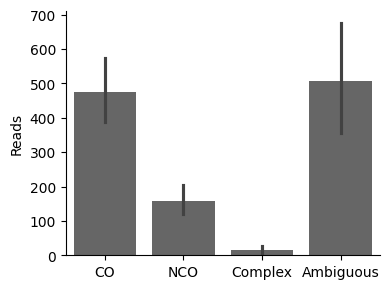

In [24]:
table_1 = (call_stats_df
    .filter(pl.col("sample_id").is_in(sample_ids))
    .rename({"GC": "NCO", "CNCO": "Complex", "ambiguous": "Ambiguous"})
    .join(
        pl.DataFrame({
            "sample_id": sample_presentation_order,
            "paper_label_id": [sample_id_to_paper_label[x] for x in sample_presentation_order]
        }),
        on="sample_id",
        how="left",
    )
    .join(coverage_per_sample, on="sample_id", how="left")
    .sort("paper_label_id", "sample_id")
    .select("paper_label_id", "sample_id", "coverage", "CO", "NCO", "Complex", "Ambiguous")
)

table_2 = (call_stats_df
    .filter(pl.col("sample_id").is_in(ceph_sample_ids_no_gps))
    .rename({"GC": "NCO", "CNCO": "Complex", "ambiguous": "Ambiguous"})
    .join(coverage_per_sample, on="sample_id", how="left")
    .sort("sample_id")
    .select("sample_id", "coverage", "CO", "NCO", "Complex", "Ambiguous")
)

with pd.ExcelWriter(table_dir / "manuscript_summary_tables.xlsx") as writer:
    table_1.to_pandas().to_excel(writer, sheet_name="Table 1", index=False)
    table_2.to_pandas().to_excel(writer, sheet_name="Table 2", index=False)

fig, ax = plt.subplots(figsize=(4, 3))
plot_df = table_1.select("paper_label_id", "CO", "NCO", "Complex", "Ambiguous").to_pandas().melt("paper_label_id")
sns.barplot(data=plot_df, x="variable", y="value", color="0.4", ax=ax)
sns.despine(ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Reads")
fig.tight_layout()
fig.savefig(figure_dir / "event_count_summary.pdf")

display(table_1)
display(table_2)
display(table_1.select("CO", "NCO", "Complex", "Ambiguous").sum())
display(table_2.select("CO", "NCO", "Complex", "Ambiguous").sum())


## Blood age effect


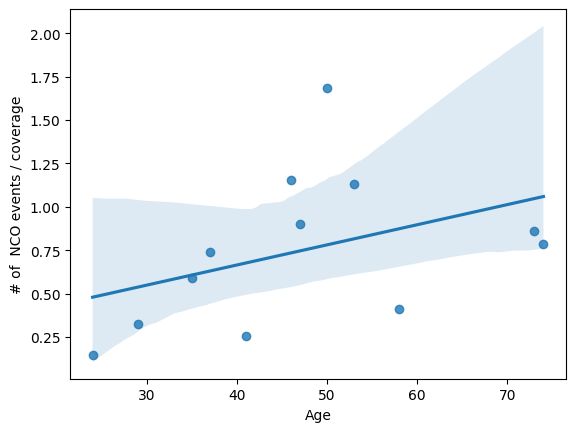

In [25]:
ceph_id_to_age = {
    '200100': 58,
    '200101': 37,
    '200102': 35,
    '200104': 29,
    '200106': 24,
    'NA12877': 74,
    'NA12878': 73,
    'NA12879': 53,
    'NA12881': 50,
    'NA12882': 47,
    'NA12885': 46,
    'NA12886': 41,
}

xdf = (call_stats_df
    .join(
        pl.DataFrame({
            "sample_id": list(ceph_id_to_age.keys()),
            "sample_age": list(ceph_id_to_age.values()),
        }),
        on="sample_id",
    )
    .join(
        coverage_per_sample,
        on="sample_id",
        how="left",
    )
    .fill_null(0)
    .with_columns(
        NCO_rate = pl.col("GC") / pl.col("coverage"),
        total_events = (pl.col("GC") + pl.col("CO") + pl.col("ambiguous") + pl.col("CNCO")),
        total_rate = (pl.col("GC") + pl.col("CO") + pl.col("ambiguous") + pl.col("CNCO")) / pl.col("coverage"),
    )
    .sort("sample_age")
)

sns.regplot(
    x="sample_age",
    y="NCO_rate",
    data=xdf,
);

plt.xlabel("Age");
plt.ylabel("# of  NCO events / coverage");

plt.rcParams["pdf.use14corefonts"] = True
fig = plt.gcf()
fig.savefig(figure_dir / "age_vs_event_counts.pdf")


In [30]:
log_factorial = lambda n: scipy.special.gammaln(n+1)

def fit_poisson_constant(coverage, n_events):
    res = scipy.optimize.minimize_scalar(
        fun = lambda L: -(
            -(L * coverage).sum() 
            + (n_events * (np.log(L * coverage))).sum()
            - log_factorial(n_events).sum()        
        ),
        bounds = (0,10000),
    )
    return res.x, -res.fun

def fit_poisson_slope_no_intercept(age, coverage, n_events):
    res = scipy.optimize.minimize_scalar(
        fun = lambda L: -(
            -(L * coverage * age).sum() 
            + (n_events * (np.log(L * coverage * age))).sum()
            - log_factorial(n_events).sum()        
        ),
        bounds = (0,10000),
    )
    
    return res.x, -res.fun

def random_dll():
    age = np.random.permutation(xdf["sample_age"])
    
    const_x, const_LL = fit_poisson_constant(xdf["coverage"], xdf["GC"])
    slope_x, slope_LL = fit_poisson_slope_no_intercept(age, xdf["coverage"], xdf["GC"])
    
    return slope_LL - const_LL

const_x, const_LL = fit_poisson_constant(xdf["coverage"], xdf["GC"])
slope_x, slope_LL = fit_poisson_slope_no_intercept(xdf["sample_age"], xdf["coverage"], xdf["GC"])
rdlls = joblib.Parallel(n_jobs=-1, verbose=1)(
    joblib.delayed(random_dll)()
    for _ in tqdm.trange(10000)
)

blood_age_slope = slope_x
blood_age_log_lr = slope_LL - const_LL
blood_age_lr = np.exp(blood_age_log_lr)
blood_age_deviance = 2 * blood_age_log_lr
blood_age_p = np.mean(np.array(rdlls) >= blood_age_log_lr)

print("slope:", blood_age_slope)
print("log LR:", blood_age_log_lr)
print("LR:", blood_age_lr)
print("2 log LR:", blood_age_deviance)
print("permutation P:", blood_age_p)




  0%|          | 0/10000 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


  1%|          | 64/10000 [00:00<00:26, 375.00it/s][Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.2s


  1%|          | 102/10000 [00:00<00:32, 304.03it/s]

  1%|▏         | 133/10000 [00:00<00:36, 268.99it/s]

  2%|▏         | 160/10000 [00:00<00:42, 229.22it/s]

  2%|▏         | 224/10000 [00:00<00:37, 262.04it/s]

  3%|▎         | 256/10000 [00:00<00:37, 257.87it/s]

  3%|▎         | 320/10000 [00:01<00:34, 283.84it/s][Parallel(n_jobs=-1)]: Done 304 tasks      | elapsed:    1.3s


  4%|▍         | 384/10000 [00:01<00:35, 273.55it/s]

  4%|▍         | 416/10000 [00:01<00:34, 277.01it/s]

  4%|▍         | 448/10000 [00:01<00:33, 282.82it/s]

  5%|▍         | 480/10000 [00:01<00:34, 278.29it/s]

  5%|▌         | 512/10000 [00:01<00:34, 275.70it/s]

  5%|▌         | 544/10000 [00:01<00:35, 266.76it/s]

  6%|▌         | 576/10000 [00:02<00:34, 274.42it/s]


slope: 0.01574210776593117
log LR: 2.824863835373094
LR: 16.858649278106373
2 log LR: 5.649727670746188
permutation P: 0.0999


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   37.8s finished


## Figures


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
/nfs/users/nfs_r/rs42/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 215 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 299 out of 330 | elapsed:   11.9s remaining:    1.2s


# of complex reads here: 188


[Parallel(n_jobs=-1)]: Done 330 out of 330 | elapsed:   14.6s finished


n_switches,len
u32,u32
3,103
4,55
5,11
6,13
7,3
8,2
9,1


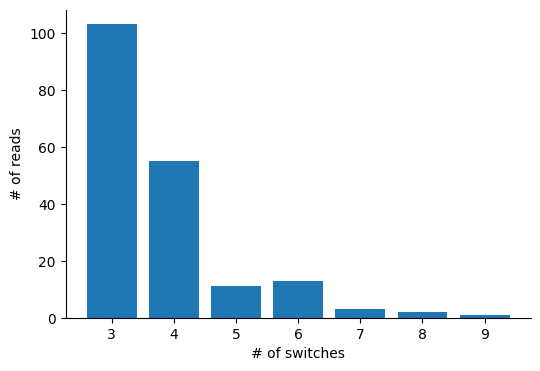

In [31]:
def F(filename):
    return (
        pl.scan_parquet(filename)
        .select(
            'read_name',
            'read_length',
            'chrom',
            'sample_id',
            'grch37_chromosome_size_in_bp',
            'high_quality_snp_positions',
            'CO_active_interval_start',
            'CO_active_interval_end',
            'CO_active_interval_length_bp',
            'grch37_reference_start',
            'grch38_reference_start',
            'grch37_reference_end',
            'grch38_reference_end',
            'grch37_reference_start_cM',
            'grch37_reference_end_cM',
            'CO_active_interval_start_cM',
            'CO_active_interval_end_cM',
            'CO_active_interval_crossover_prob',
            "mid_CO_active_interval_crossover_prob",
            'AA_motif_center_pos',
            'AA_heat',
            'AA_motif_strand',
            'CL4_motif_center_pos',
            'CL4_heat',
            'CL4_motif_strand',
            'is_high_quality_read',
            "min_coverage_hap1",
            "min_coverage_hap2",
            "high_quality_classification_class",
            "snp_positions_on_read", 
            "idx_transitions",
            "H3K4me3_signal_mean",
            "CTCF_signal_sum",
            "CTCF_signal_mean",
            "high_quality_classification_in_detectable_class",
            "full_read_crossover_prob",
            "total_mismatches",
            "is_contamination",
        )
        .filter(pl.col("high_quality_classification_class") == "CNCO")
        .filter(~pl.col("is_contamination"))
        .filter("is_high_quality_read")
        .filter(pl.col("CO_active_interval_crossover_prob") > 0)
        .collect(streaming=True)
    )
    
dense_reads_with_detection_df = pl.concat(
    joblib.Parallel(n_jobs=-1, verbose=1)(
        joblib.delayed(F)(filename) for filename in reads_filenames
    )
)

print("# of complex reads here:", len(dense_reads_with_detection_df))

n_switches_df = (dense_reads_with_detection_df
    .select(pl.col("idx_transitions").list.len().alias("n_switches"))
    .group_by("n_switches")
    .len()
    .sort("n_switches")
)

display(n_switches_df)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    x = n_switches_df["n_switches"],
    height = n_switches_df["len"],
);

sns.despine(ax=ax);
ax.set_xlabel("# of switches");
ax.set_ylabel("# of reads");

plt.rcParams["pdf.use14corefonts"] = True
fig.savefig(figure_dir / "complex_switch_count_distribution.pdf")


In [32]:
sperm_event_counts = table_1.select("CO", "NCO", "Ambiguous", "Complex").sum().to_dicts()[0]
blood_event_counts = table_2.select("CO", "NCO", "Ambiguous", "Complex").sum().to_dicts()[0]

key_values = {
    "sperm total reads": int(sperm_total_reads),
    "high-quality reads": int(n_high_quality_reads),
    "sperm read SNV calls": int(n_sperm_read_snv_calls),
    "high-quality SNVs": int(n_high_quality_snvs),
    "reads with high-quality SNVs": int(n_reads_with_high_quality_snvs),
    "mean SNVs/read": float(mean_snvs_per_read),
    "blood high-quality SNVs": int(n_blood_high_quality_snvs),
    "sperm classified reads": int(n_sperm_classified_reads),
    "mean read length, sperm": float(sperm_mean_read_length),
    "mean read length, CEPH blood": float(blood_mean_read_length),
    "sperm event counts": sperm_event_counts,
    "blood event counts": blood_event_counts,
    "complex-analysis reads": int(len(dense_reads_with_detection_df)),
    "blood age slope": float(blood_age_slope),
    "blood age log LR": float(blood_age_log_lr),
    "blood age LR": float(blood_age_lr),
    "blood age 2 log LR": float(blood_age_deviance),
    "blood age permutation P": float(blood_age_p),
}

key_values


{'sperm total reads': 267461560,
 'high-quality reads': 196296004,
 'sperm read SNV calls': 3021086931,
 'high-quality SNVs': 1163633539,
 'reads with high-quality SNVs': 173695261,
 'mean SNVs/read': 6.699282020135253,
 'blood high-quality SNVs': 389685716,
 'sperm classified reads': 65446,
 'mean read length, sperm': 13160.820895532914,
 'mean read length, CEPH blood': 14479.788050218396,
 'sperm event counts': {'CO': 7143,
  'NCO': 2382,
  'Ambiguous': 7585,
  'Complex': 219},
 'blood event counts': {'CO': 11, 'NCO': 369, 'Ambiguous': 143, 'Complex': 9},
 'complex-analysis reads': 188,
 'blood age slope': 0.01574210776593117,
 'blood age log LR': 2.824863835373094,
 'blood age LR': 16.858649278106373,
 'blood age 2 log LR': 5.649727670746188,
 'blood age permutation P': 0.0999}